In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [2]:
# Geometry
tile_size_cm = 10
n_pixels = 20
pixel_size_cm = tile_size_cm / n_pixels  # 0.5 cm = 5 mm

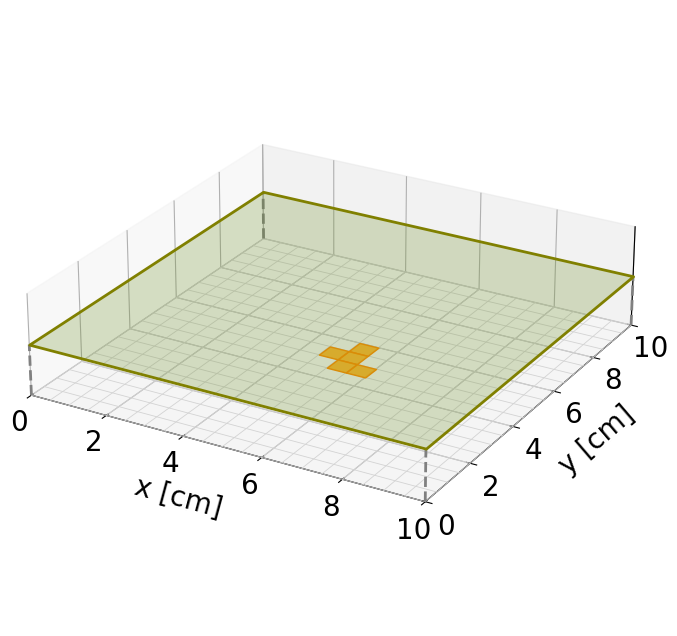

In [22]:
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = '3d')

# z positions
z_pixels = 0
z_tile = 0.5

# Draw pixel grid on the bottom plane
for i in range(n_pixels + 1):
    x = i * pixel_size_cm
    y = i * pixel_size_cm
    ax.plot([x, x], [0, tile_size_cm], [z_pixels, z_pixels],
            color = 'lightgray', linewidth = 0.6)
    ax.plot([0, tile_size_cm], [y, y], [z_pixels, z_pixels],
            color = 'lightgray', linewidth = 0.6)

# Highlight a few pixels near the center
center_pixels = [(9, 10), (10, 9), (10, 10), (10, 11), (11, 9)]

for ix, iy in center_pixels:
    x0 = ix * pixel_size_cm
    y0 = iy * pixel_size_cm
    pixel = [[
        (x0, y0, z_pixels),
        (x0 + pixel_size_cm, y0, z_pixels),
        (x0 + pixel_size_cm, y0 + pixel_size_cm, z_pixels),
        (x0, y0 + pixel_size_cm, z_pixels)
    ]]

    ax.add_collection3d(
        Poly3DCollection(pixel, facecolors = 'orange', edgecolors = 'darkorange', alpha = 0.8)
    )

# Draw transparent tile on top
tile = [
    [(0, 0, z_tile), (tile_size_cm, 0, z_tile),
     (tile_size_cm, tile_size_cm, z_tile), (0, tile_size_cm, z_tile)]
]
ax.add_collection3d(
    Poly3DCollection(tile, facecolors = 'olivedrab', edgecolors = 'olive', alpha = 0.25, linewidth = 2)
)

# Optional vertical corner lines to emphasize separation
corners = [(0, 0), (tile_size_cm, 0), (tile_size_cm, tile_size_cm), (0, tile_size_cm)]
for x, y in corners:
    ax.plot([x, x], [y, y], [z_pixels, z_tile], color = 'gray', linestyle = '--', linewidth = 2)

# Labels and view
ax.set_xlim(0, tile_size_cm)
ax.set_ylim(0, tile_size_cm)
ax.set_zlim(0, 1)
ax.tick_params(axis = "both", labelsize = 20)
ax.set_xlabel('x [cm]', fontsize = 20, labelpad = 20)
ax.set_ylabel('y [cm]', fontsize = 20, labelpad = 15)
ax.set_zlabel('')
ax.set_zticks([])
# ax.set_title('3D View of 10×10 cm² Transparent Tile over 20×20 Pixels')

ax.view_init(elev = 25, azim = -60)
ax.set_box_aspect((1, 1, 0.25))